In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

data = pd.read_csv("ecommerce_sales.csv")

data["order_date"] = pd.to_datetime(data["order_date"])
data["year"] = data["order_date"].dt.year
print(data.dtypes)

data.head()

order_id                     int64
order_date          datetime64[ns]
customer_id                  int64
product_category            object
region                      object
quantity                     int64
unit_price                 float64
discount                   float64
payment_method              object
delivery_days                int64
customer_rating            float64
revenue                    float64
year                         int32
dtype: object


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022


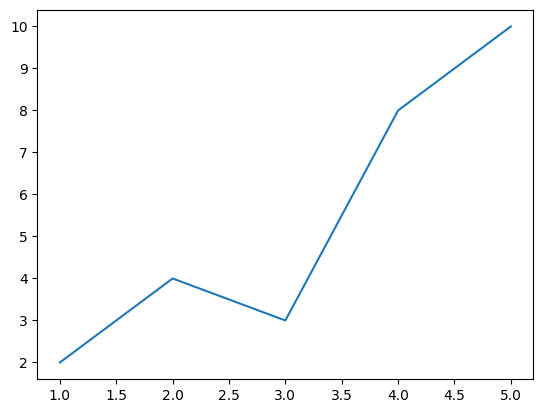

In [3]:
x_values = [1, 2, 3, 4, 5]
y_values = [2, 4, 3, 8, 10]
plt.plot(x_values, y_values)

['South' 'East' 'West' 'North']
region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64


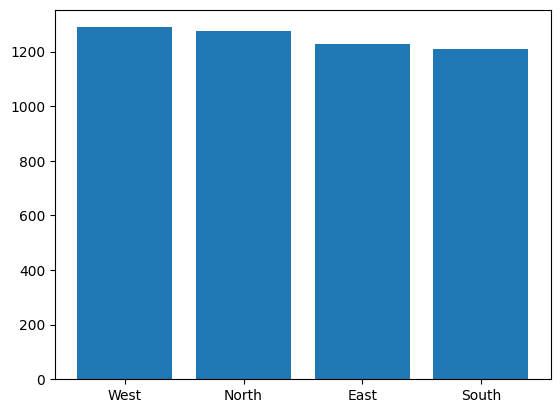

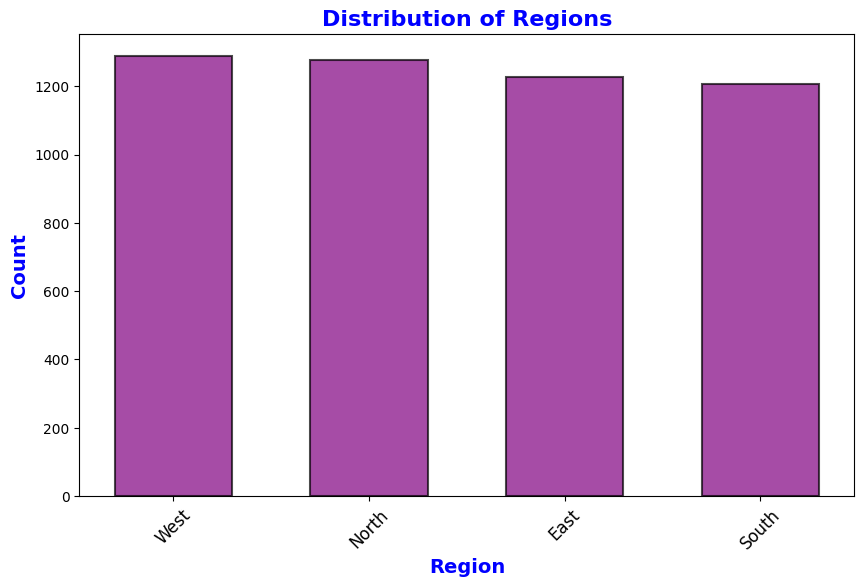

In [4]:
# Univariate Analysis(Bar Chart)
print(data["region"].unique())
cat_counts = data["region"].value_counts()  # count of each unique value
print(cat_counts)
x_bar = cat_counts.index
y_bar = cat_counts.values
plt.bar(x_bar, y_bar)

# to resolve overlapping of x-axis labels, we can rotate the labels,increase the figure size, or use a horizontal bar chart. Here, we will increase the figure size.
plt.figure(figsize=(10, 6))  # 1. increasing the figure size
plt.bar(
    x_bar, y_bar, color="purple", edgecolor="black", alpha=0.7, width=0.6, linewidth=1.5
)
# color = color of the bars, edgecolor = color of the border of the bars, alpha = transparency of the bars, width = width of the bars, linewidth = thickness of the border of the bars
plt.xticks(rotation=45, fontsize=12)  # 2. rotating the x-axis labels

# Also you can add labels
plt.xlabel("Region", fontsize=14, fontweight="bold", color="blue")
plt.ylabel("Count", fontsize=14, fontweight="bold", color="blue")
plt.title("Distribution of Regions", fontsize=16, fontweight="bold", color="blue")
plt.savefig(
    "region_distribution.png", dpi=300, bbox_inches="tight"
)  # save the figure as a png file , dpi = resolution of the figure, bbox_inches = to remove the white space around the figure
plt.show()

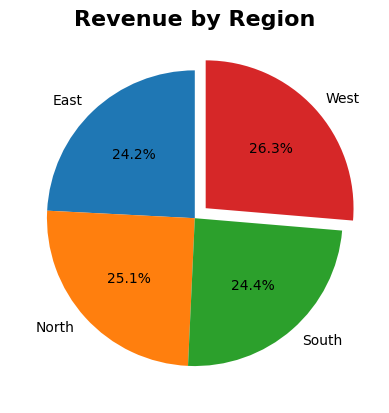

In [5]:
# pie chart : instead of count if youre interested in showing proportion/%
revenue_by_region = data.groupby("region")["revenue"].sum()
plt.pie(
    revenue_by_region,
    labels=revenue_by_region.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0, 0, 0.1),
)  # , colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
# labels = to show the labels of each slice, autopct = to show the percentage of each slice, startangle = to rotate the pie chart, colors = to change the color of the slices,explode = to separate the slices of the pie chart
plt.title("Revenue by Region", fontsize=16, fontweight="bold", color="black")
plt.show()

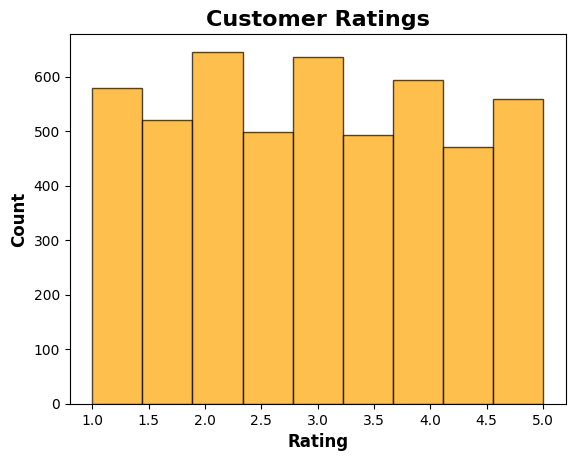

In [6]:
# Histogram is used to visualize statistical distribution of a continuous variable. It is a type of bar chart that groups data into bins and displays the frequency of data points in each bin.
# 1. to display statistics : shows the distribution of data points across different value ranges
# 2. to point outliers : bars that are far away from the rest of the data way too small or way too large
plt.hist(data["customer_rating"], bins=9, color="orange", edgecolor="black", alpha=0.7)
# bins = number of bins, color = color of the bars, edgecolor = color of the border of the bars, alpha = transparency of the bars
plt.xlabel("Rating", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.title("Customer Ratings", fontsize=16, fontweight="bold")
plt.show()
# skewness: if the histogram is skewed to the left, it means that the data is negatively skewed, if the histogram is skewed to the right, it means that the data is positively skewed, if the histogram is symmetric, it means that the data is normally distributed.
# example: left long tail = negatively skewed, right long tail = positively skewed, bell shaped = normally distributed

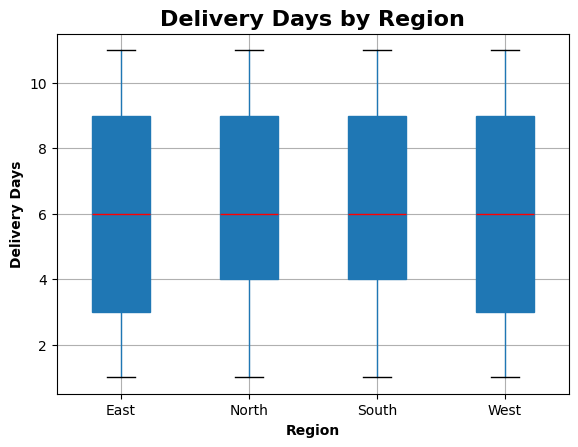

In [7]:
# Box plot is used to visualize the distribution of a continuous variable and to identify outliers. It shows the median, quartiles, and outliers of the data.
data.boxplot(
    column="delivery_days",
    by="region",
    patch_artist=True,
    medianprops=dict(color="red"),
)
# grid = False : to remove the grid lines, patch_artist = True : to fill the box with color, medianprops = dict(color="red") : to change the color of the median line
plt.title("Delivery Days by Region", fontsize=16, fontweight="bold")
plt.suptitle("")
plt.xlabel("Region", fontweight="bold")
plt.ylabel("Delivery Days", fontweight="bold")
plt.show()

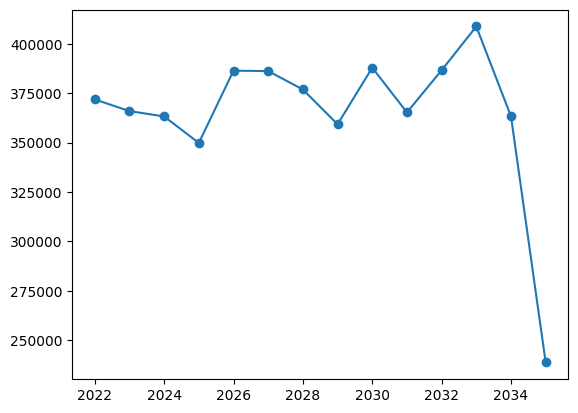

In [8]:
# Bivariate Analysis
# Line Chart : to visualize the relationship between two continuous variables. It is used to show trends over time or to compare two variables.

sales = data.groupby("year")["revenue"].sum()
plt.plot(sales.index, sales.values, marker="o")
# plt.xlim(2025, 2035)  # to set the x-axis limits

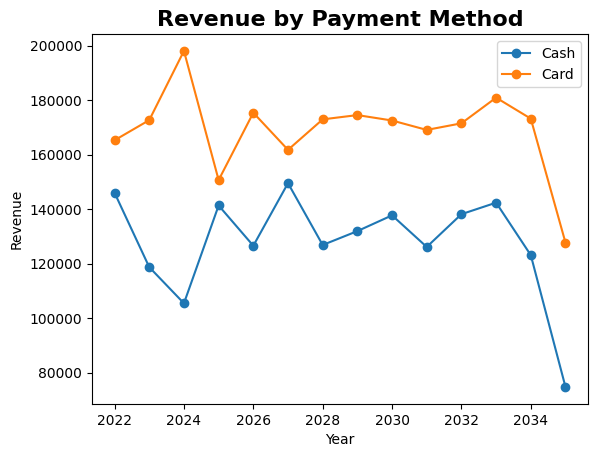

In [9]:
# Multiple Line Chart : to visualize the relationship between two continuous variables. It is used to show trends over time or to compare two variables.
cash = data.loc[data["payment_method"] == "COD"]
card = data.loc[data["payment_method"] == "Card"]
plt.plot(cash.groupby("year")["revenue"].sum(), marker="o", label="Cash")
plt.plot(card.groupby("year")["revenue"].sum(), marker="o", label="Card")
plt.title("Revenue by Payment Method", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend()

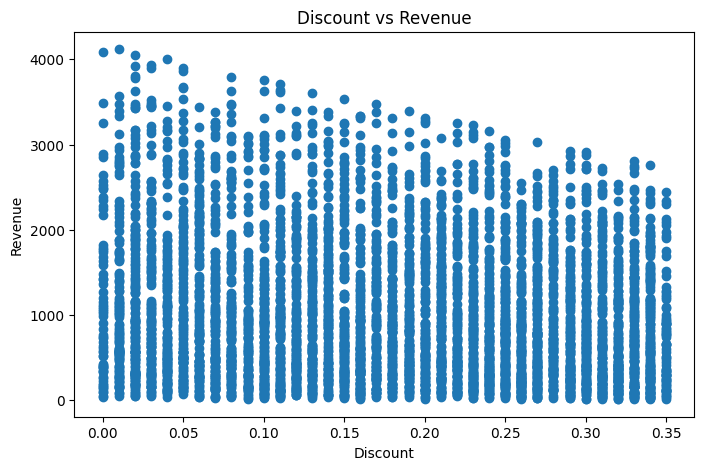

In [10]:
# Scatter Plot is used to visualize the relationship between two continuous variables. It is used to show the correlation between two variables.
# correlation: if the points are scattered in a linear pattern, it means that there is a strong correlation between the two variables, if the points are scattered in a random pattern, it means that there is no correlation between the two variables.
plt.figure(figsize=(8, 5))
plt.scatter(data["discount"], data["revenue"])
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.title("Discount vs Revenue")
plt.show()

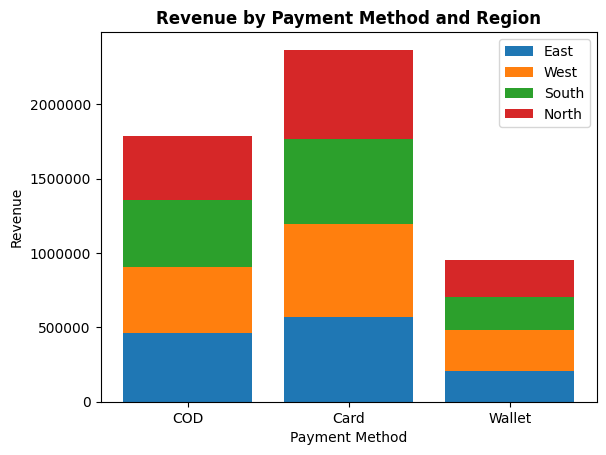

In [11]:
# stacked bar chart : to visualize the relationship between two categorical variables. It is used to show the distribution of one categorical variable across the levels of another categorical variable.
east = data.loc[data["region"] == "East"].groupby("payment_method")["revenue"].sum()
west = data.loc[data["region"] == "West"].groupby("payment_method")["revenue"].sum()
south = data.loc[data["region"] == "South"].groupby("payment_method")["revenue"].sum()
north = data.loc[data["region"] == "North"].groupby("payment_method")["revenue"].sum()

plt.bar(east.index, east, label="East")
plt.bar(west.index, west, bottom=east, label="West")  # bottom means
plt.bar(south.index, south, bottom=east + west, label="South")
plt.bar(north.index, north, bottom=east + west + south, label="North")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.title("Revenue by Payment Method and Region", fontweight="bold")
plt.legend()

plt.ticklabel_format(style="plain", axis="y")

plt.show()

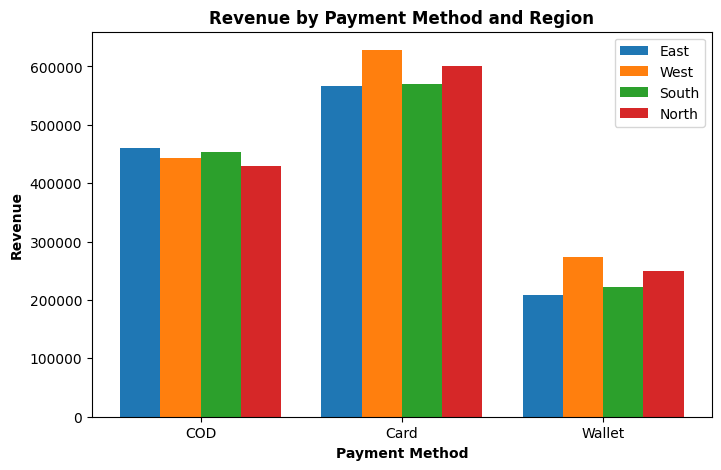

Index(['COD', 'Card', 'Wallet'], dtype='object', name='payment_method')

In [12]:
# dodged
import numpy as np

x = np.arange(len(east.index))
width = 0.2

plt.figure(figsize=(8, 5))
plt.bar(x - 1.5 * width, east, width, label="East")
plt.bar(x - 0.5 * width, west, width, label="West")
plt.bar(x + 0.5 * width, south, width, label="South")
plt.bar(x + 1.5 * width, north, width, label="North")

plt.xticks(x, east.index)
plt.legend()
plt.xlabel("Payment Method", fontweight="bold")
plt.ylabel("Revenue", fontweight="bold")
plt.title("Revenue by Payment Method and Region", fontweight="bold")

plt.show()
east.index

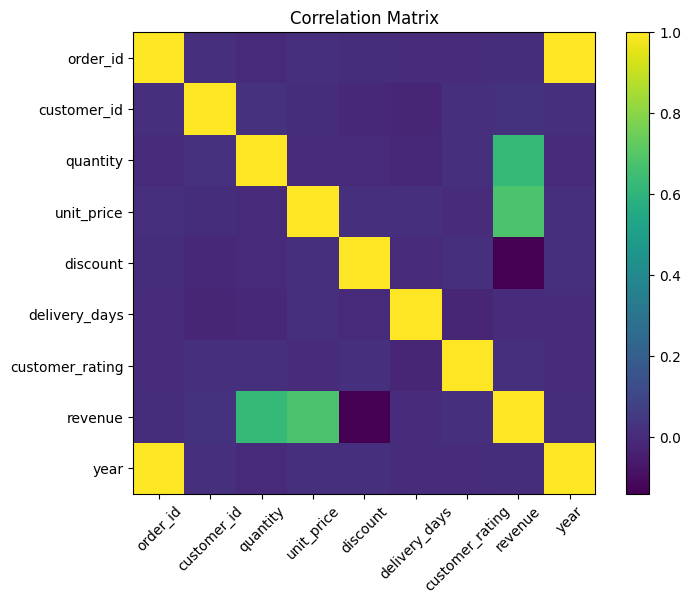

In [13]:
# Heat map : grid structured , work with nummerical data
# correlation (-1 to 1):is a quantitative relationship

dat = data.select_dtypes(include="number")
corr = dat.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

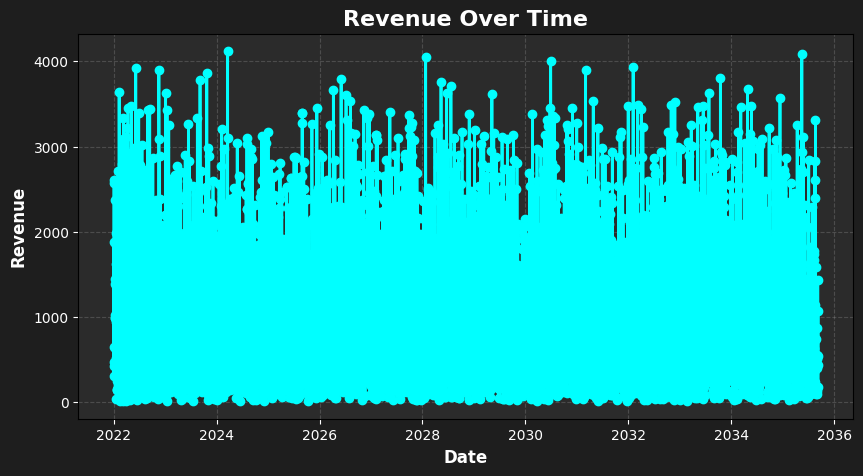

In [14]:
daily_sales = data.groupby('order_date')['revenue'].sum()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker='o',color='cyan', linewidth=2,
)

plt.title('Revenue Over Time', fontsize=16, fontweight='bold', color='white')
plt.xlabel('Date', fontsize=12, fontweight='bold', color='white')
plt.ylabel('Revenue', fontsize=12, fontweight='bold', color='white')
plt.tick_params(axis='both', colors='white')
plt.grid(linestyle="--", alpha=0.25)

plt.show()